In [7]:
import pandas as pd

df = pd.read_csv("sample_data/Sample - Superstore.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
# عرض القيم الفارغة
print(df.isnull().sum())

# حذف القيم الفارغة (بسيط كبداية)
df = df.dropna()

print("After cleaning:", df.shape)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
After cleaning: (9994, 21)


In [9]:
# أفضل المدن
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_cities)

City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64


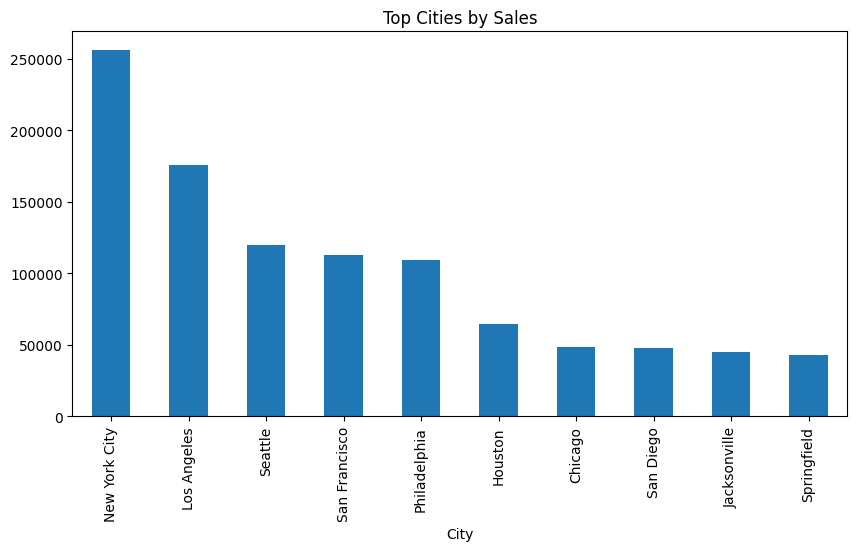

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')
plt.title("Top Cities by Sales")
plt.show()

In [11]:
# أفضل المنتجات
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


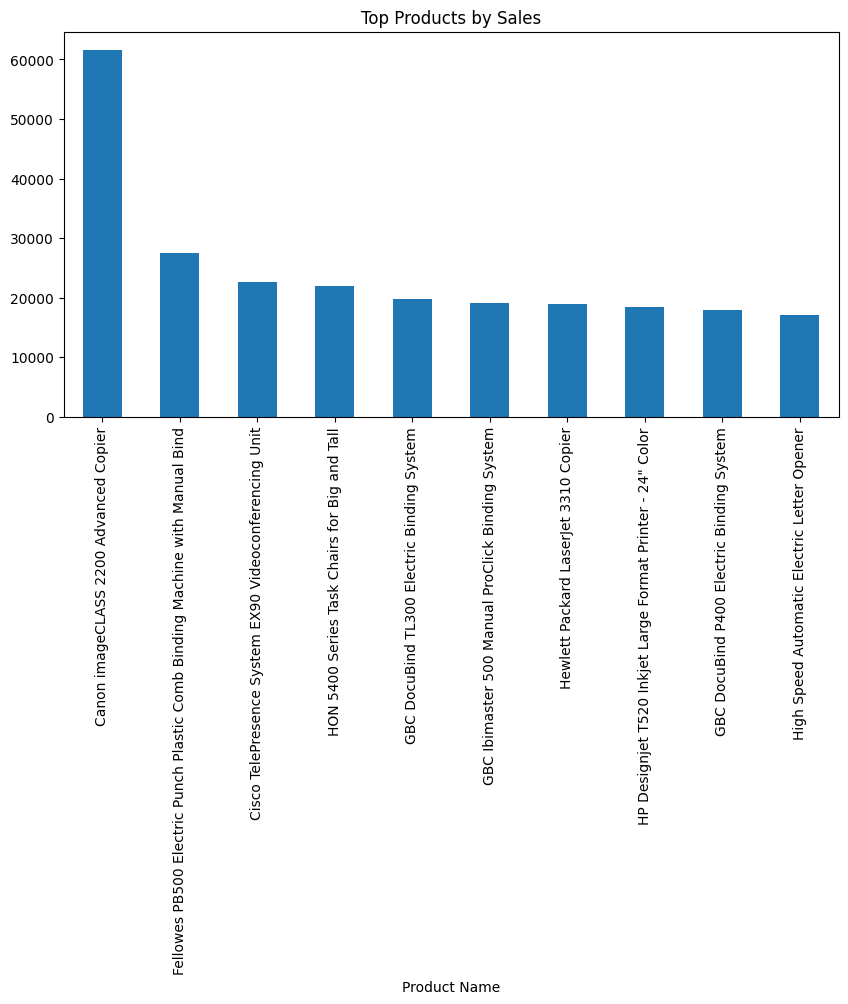

In [12]:
plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title("Top Products by Sales")
plt.show()

In [13]:
profit_by_category = df.groupby('Category')['Profit'].sum()

print(profit_by_category)

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


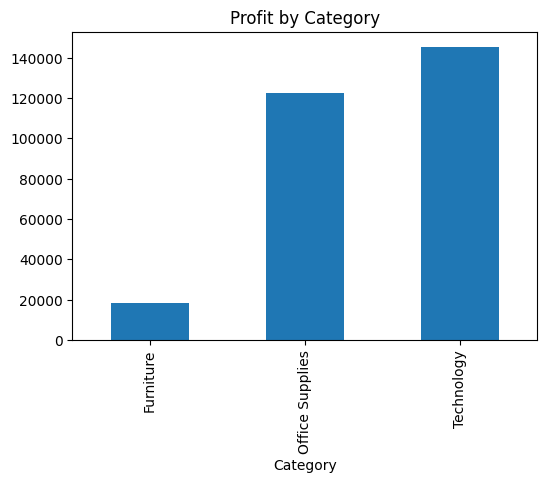

In [14]:
plt.figure(figsize=(6,4))
profit_by_category.plot(kind='bar')
plt.title("Profit by Category")
plt.show()

In [15]:
from sklearn.linear_model import LinearRegression

# تحويل التاريخ
df['Order Date'] = pd.to_datetime(df['Order Date'])

# استخراج السنة
df['Year'] = df['Order Date'].dt.year

# تجميع المبيعات حسب السنة
sales_year = df.groupby('Year')['Sales'].sum().reset_index()

print(sales_year)

   Year        Sales
0  2014  484247.4981
1  2015  470532.5090
2  2016  609205.5980
3  2017  733215.2552


In [16]:
model = LinearRegression()

model.fit(sales_year[['Year']], sales_year['Sales'])

# توقع المستقبل
future = pd.DataFrame({'Year': [2017, 2018]})
prediction = model.predict(future)

print("Future Sales Prediction:", prediction)

Future Sales Prediction: [707136.66911998 795694.30514997]


In [17]:
# Built a sales forecasting model using Linear Regression
# Identified a consistent upward trend in annual sales
# Predicted future growth
